# Post → donation linkage (Hiraya Haven)

**Pipeline:** Model which social posts are associated with referred donations and estimate expected referred value.

**Data:** `social_media_posts`, `donations` (join on `donations.referral_post_id = social_media_posts.post_id`) from `../Data/hiraya.db`.

**Predictive:** Classify whether a post will refer ≥1 donation (or predict `donation_referrals`).

**Explanatory:** Identify which post attributes (platform, post type, boosted, call-to-action, time of day, engagement) correlate with donation referral outcomes.

> Bias note: Boosting and campaign timing introduce selection bias; interpret as association, not causal effect.

> **IS455 pipeline structure:** (1) Problem framing → (2) Data acquisition, preparation & exploration → (3) Modeling → (4) Evaluation & selection → (5) Feature selection & interpretation → (6) Explanatory analysis (associations; not causal proof) → (7) Deployment.

## 1. Problem framing

Hiraya Haven relies heavily on social media to reach donors, but leadership needs to know **what to post** and **where** to focus effort (`IntexContext.txt`).

**Business question:** *Which post characteristics are associated with donations attributed to a post, and can we predict donation referral likelihood/value for future posts?*

- **Predictive goal:** estimate `will_refer_donation` and/or `estimated_donation_value_php`.
- **Explanatory goal:** interpret the strongest correlates (CTA, boosted, platform, topic, timing).

**Success metrics:** ROC-AUC / AP for classification; MAE for value regression.

## 2. Data acquisition, preparation & exploration

Data comes from `social_media_posts` and `donations` in `../Data/hiraya.db`.

- We create post-level outcomes from the platform-like fields (`donation_referrals`, `estimated_donation_value_php`).
- We build features from post metadata (platform, topic, CTA) and (optionally) engagement metrics.

**Leakage note:** If the goal is “predict performance before posting,” exclude engagement metrics (they occur after posting). This notebook keeps them as a separate, more realistic “post-performance” predictor set.

In [1]:
# ============================================================================
# Post → donation linkage — Load posts and define referral outcomes
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Binary target will_refer_donation from donation_referrals > 0.
# estimated_donation_value_php supports a secondary regression target (rough business value).
#
from __future__ import annotations

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import average_precision_score, mean_absolute_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DB_PATH = ROOT / "Data" / "hiraya.db"

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH}")


def read_table(conn: sqlite3.Connection, table: str) -> pd.DataFrame:
    return pd.read_sql_query(f'SELECT * FROM "{table}"', conn)


with sqlite3.connect(DB_PATH) as conn:
    posts = read_table(conn, "social_media_posts")
    donations = read_table(conn, "donations")

posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")

# Post-level outcomes
# Use platform-side fields if populated (donation_referrals, estimated_donation_value_php)
outcomes = posts[["post_id", "donation_referrals", "estimated_donation_value_php"]].copy()
outcomes["donation_referrals"] = outcomes["donation_referrals"].fillna(0).astype(int)
outcomes["estimated_donation_value_php"] = outcomes["estimated_donation_value_php"].fillna(0.0)

posts_ml = posts.merge(outcomes, on="post_id", how="left", suffixes=("", "_out"))
posts_ml["will_refer_donation"] = (posts_ml["donation_referrals"] > 0).astype(int)

posts_ml[["donation_referrals", "will_refer_donation", "estimated_donation_value_php"]].describe()

,donation_referrals,will_refer_donation,estimated_donation_value_php
count,812.000000,812.000000,8.120000e+02
mean,12.795567,0.642857,3.977209e+04
std,31.261714,0.479453,1.240811e+05
min,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000e+00
50%,2.000000,1.000000,4.556955e+03
75%,11.000000,1.000000,3.007207e+04
max,458.000000,1.000000,2.402436e+06


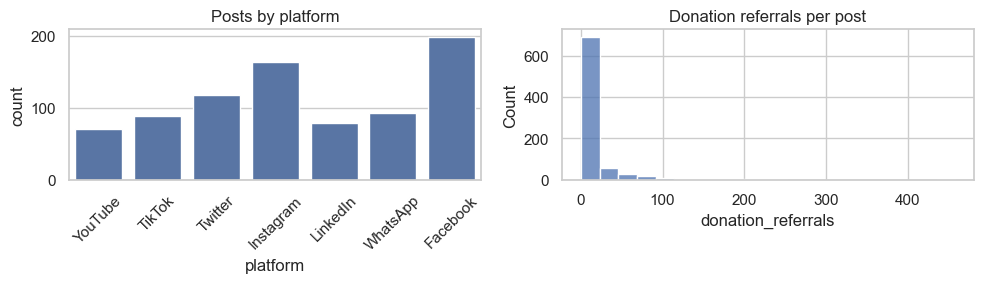

platform
YouTube      0.774648
TikTok       0.752809
Instagram    0.682927
WhatsApp     0.645161
Twitter      0.632479
Facebook     0.613065
LinkedIn     0.405063
Name: will_refer_donation, dtype: float64

In [2]:
# ============================================================================
# EDA — Platform distribution and referral count histogram
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Sanity-check class imbalance and which platforms drive volume.
#
# Basic EDA

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.countplot(x="platform", data=posts_ml, ax=axes[0])
axes[0].set_title("Posts by platform")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(posts_ml["donation_referrals"], bins=20, ax=axes[1])
axes[1].set_title("Donation referrals per post")

plt.tight_layout()
plt.show()

posts_ml.groupby("platform")["will_refer_donation"].mean().sort_values(ascending=False)

## 3. Modeling

We use a simple, deployable baseline:

- **Classification:** `will_refer_donation` (logistic regression)
- **Regression:** `estimated_donation_value_php` (ridge regression)

Features include platform + content fields and basic engagement metrics.

**Leakage note:** We avoid using any fields that are direct post-hoc donation labels beyond the targets (e.g., we do not use `donation_referrals` as an input). Engagement metrics are treated as known outcomes of the post; if you want a *pre-post* content-only model, exclude engagement metrics too.

In [3]:
# ============================================================================
# Classification — Predict referral from content + performance features
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Includes engagement variables (likes, reach, …); strong performance may reflect leakage if
#   measured after posting — compare to content-only out-of-time eval in cell 11.
# Stratified split keeps positive rate stable in train/test for ROC/AP.
#
# Feature set

feature_cols_cat = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "is_boosted",
    "has_call_to_action",
]

feature_cols_num = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    # engagement
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
]

df = posts_ml.copy()
X = df[feature_cols_cat + feature_cols_num].copy()

# Targets
y_cls = df["will_refer_donation"].astype(int)
y_val = df["estimated_donation_value_php"].astype(float)

# One stratified split for both classification and regression (same rows in train/test).
_idx = np.arange(len(df))
idx_train, idx_test = train_test_split(
    _idx, test_size=0.25, random_state=42, stratify=y_cls
)
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y_cls.iloc[idx_train], y_cls.iloc[idx_test]

pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
        ("num", Pipeline([("scaler", StandardScaler())]), feature_cols_num),
    ]
)

clf = Pipeline(
    steps=[
        ("pre", pre),
        ("lr", LogisticRegression(max_iter=500, class_weight="balanced", solver="liblinear")),
    ]
)

clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, proba) if y_test.nunique() > 1 else float("nan")
ap = average_precision_score(y_test, proba)

print(f"Classification: ROC-AUC={roc:.3f} AP={ap:.3f}")

Classification: ROC-AUC=0.978 AP=0.986


In [4]:
# ============================================================================
# Regression — Estimated PHP from features
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Treat estimated_donation_value_php as a noisy label; MAE is for relative model comparison only.
#
# Value regression (conditional on features)
# Note: estimated_donation_value_php is a derived metric; interpret as association.

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y_val.iloc[idx_train], y_val.iloc[idx_test]

reg = Pipeline(
    steps=[
        ("pre", pre),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

reg.fit(X_train, y_train)
pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, pred)
print(f"Value regression: MAE={mae:.2f} PHP")

Value regression: MAE=38322.94 PHP


## 4. Evaluation & selection

- **Classification:** report ROC-AUC and Average Precision (AP). Explain what it means operationally (e.g., selecting top 10% posts to emulate).
- **Regression:** report MAE in PHP for referred value.

**Practical takeaway:** use rankings and templates, not point estimates, for content planning.

## 5. Feature selection & interpretation

Use **logistic / ridge coefficients** after one-hot scaling as the primary interpretability layer; compare **content-only** vs **post-performance** feature sets in the add-on cell.

## 6. Explanatory analysis (associations; not causal proof)

This pipeline surfaces **correlates** of donation referrals.

- **Selection bias:** boosted posts and campaign posts may be systematically different from organic content.
- **Post-treatment variables:** engagement metrics are partly outcomes of the post and can be influenced by boosting.

Treat the explanatory output as “what tends to co-occur with donation referrals in this dataset,” not as proof that changing one knob will cause more donations.

## 7. Deployment

- Add a “Post recommendations” admin screen that displays:
  - predicted referral probability
  - predicted referred value
  - top feature drivers (via coefficients)
- Use this as guidance for posting strategy (platform + timing + CTA), then monitor real outcomes to update the model.

## Add-on: stricter evaluation (out-of-time) and pre-post model

Per Chapter 15 (evaluation discipline), a **time split** is a better approximation of deployment than a random split.

Also, if the goal is to predict performance *before* a post is published, exclude engagement metrics (they occur after posting).

In [5]:
# ============================================================================
# Out-of-time + content-only vs full performance features
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Trains on older posts; tests on newer — better mimic of deployment.
# Two feature sets isolate whether captions/topics alone explain referrals vs needing reach/engagement.
#
# Out-of-time split by created_at

df_time = posts_ml.dropna(subset=["created_at"]).sort_values("created_at").copy()
cut = df_time["created_at"].quantile(0.75)
train_mask = df_time["created_at"] < cut

# Two feature sets: content-only vs post-performance (includes engagement)
feature_cols_num_content = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
]

feature_cols_num_perf = feature_cols_num_content + [
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
]

X_content = df_time[feature_cols_cat + feature_cols_num_content]
X_perf = df_time[feature_cols_cat + feature_cols_num_perf]

y_cls = df_time["will_refer_donation"].astype(int)

def fit_eval(X, y, label: str):
    pre = ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
            ("num", Pipeline([("scaler", StandardScaler())]), [c for c in X.columns if c not in feature_cols_cat]),
        ]
    )
    clf = Pipeline(
        [
            ("pre", pre),
            ("lr", LogisticRegression(max_iter=500, class_weight="balanced", solver="liblinear")),
        ]
    )
    clf.fit(X[train_mask], y[train_mask])
    proba = clf.predict_proba(X[~train_mask])[:, 1]
    roc = roc_auc_score(y[~train_mask], proba) if y[~train_mask].nunique() > 1 else float("nan")
    ap = average_precision_score(y[~train_mask], proba)
    print(f"{label}: out-of-time ROC-AUC={roc:.3f} AP={ap:.3f}")

fit_eval(X_content, y_cls, "Content-only")
fit_eval(X_perf, y_cls, "Post-performance (includes engagement)")

Content-only: out-of-time ROC-AUC=0.845 AP=0.909
Post-performance (includes engagement): out-of-time ROC-AUC=0.943 AP=0.971
